In [1]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

In [2]:
# Models
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
# ============================
# 2. Load Dataset
# ============================
df = pd.read_csv('Telco_customer_churn.csv')

In [4]:
# ============================
# 3. Basic Cleaning
# ============================
# Convert Total Charges to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_24488\1399698437.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


In [5]:
# Drop unnecessary columns
drop_cols = ['CustomerID', 'Count', 'Churn Value', 'Churn Score',
             'Country', 'State', 'City', 'Zip Code', 'Lat Long',
             'Latitude', 'Longitude', 'Churn Reason']
df.drop(columns=drop_cols, inplace=True)

In [6]:
# ============================
# 4. Encoding Categorical Features
# ============================

# Check Binary categorical variables
binary_cols = df.select_dtypes(include=['object']).nunique()
print("Binary Categorical Columns and their unique values:\n", binary_cols[binary_cols == 2])


Binary Categorical Columns and their unique values:
 Gender               2
Senior Citizen       2
Partner              2
Dependents           2
Phone Service        2
Paperless Billing    2
Churn Label          2
dtype: int64


In [7]:
# Binary columns (Yes/No)
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing', 'Churn Label']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [8]:
# Check Multiclass categorical
multiclass_cols = df.select_dtypes(include=['object']).nunique()
print("Multiclass Categorical Columns and their unique values:\n", multiclass_cols[multiclass_cols > 2])


Multiclass Categorical Columns and their unique values:
 Multiple Lines       3
Internet Service     3
Online Security      3
Online Backup        3
Device Protection    3
Tech Support         3
Streaming TV         3
Streaming Movies     3
Contract             3
Payment Method       4
dtype: int64


In [9]:
service_cols = ['Multiple Lines', 'Online Security', 'Online Backup',
                'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for col in service_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

In [10]:
# One-hot encode remaining multiclass columns
df = pd.get_dummies(df, columns=['Internet Service', 'Payment Method'], drop_first=True)


In [11]:
# Contract-Ordinal encoding
contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_mapping)


In [12]:
# ============================
# 5. Feature Engineering
# ============================

# Tenure group
df['tenure_group'] = pd.cut(df['Tenure Months'],
                            bins=[-1, 12, 36, 72],
                            labels=[0, 1, 2]).astype(int)

# Average monthly spend
df['avg_monthly_spend'] = np.where(df['Tenure Months'] > 0,
                                   df['Total Charges'] / df['Tenure Months'],
                                   df['Monthly Charges'])
df['avg_monthly_spend'] = df['avg_monthly_spend'].round(2)

# High value customer
df['High Value Customer'] = (df['avg_monthly_spend'] > 70).astype(int)

# Number of add-on services
add_on_cols = ['Online Security', 'Online Backup', 'Device Protection',
               'Tech Support', 'Streaming TV', 'Streaming Movies']
df['Add-on Services'] = df[add_on_cols].sum(axis=1)

# Charge per service
df['Charge per Service'] = df['Monthly Charges'] / (df['Add-on Services'] + 1)

In [13]:
# ============================
# 6. Prepare X and y
# ============================
X = df.drop(columns=['Churn Label'])
y = df['Churn Label']   

In [14]:
# ============================
# 7. Train-Test Split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# ============================
# 8. Scaling Numerical Features
# ============================
numerical_features = ['Tenure Months', 'Monthly Charges', 'Total Charges',
                      'avg_monthly_spend', 'Charge per Service']

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features]  = scaler.transform(X_test[numerical_features])

In [16]:
# Check Class Imbalance
print("Class distribution in training set:\n", y_train.value_counts())


Class distribution in training set:
 Churn Label
0    4139
1    1495
Name: count, dtype: int64


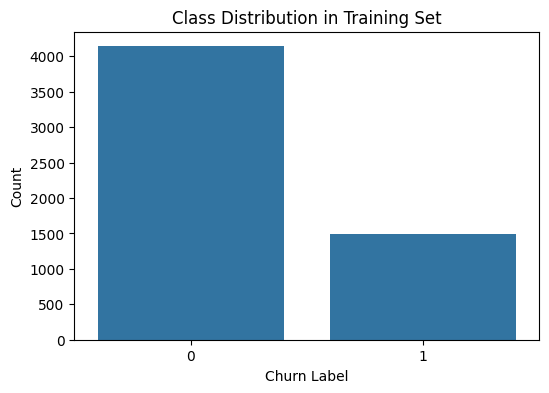

In [17]:
# Visualize class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.show()

Class distribution before resampling:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Class distribution after SMOTETomek:
Churn Label
0    3967
1    3967
Name: count, dtype: int64


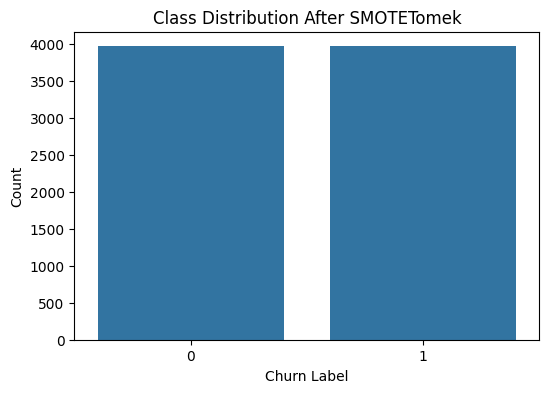

In [18]:
# ============================
# 9. Handle Class Imbalance with SMOTETomek (or Borderline-SMOTE)
# ============================

from imblearn.combine import SMOTETomek

print("Class distribution before resampling:")
print(y_train.value_counts())

# Use SMOTETomek
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTETomek:")
print(y_train_res.value_counts())

# Optional visualization
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res)
plt.title('Class Distribution After SMOTETomek')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.show()

In [19]:
# ============================
# 10. Model Training & Evaluation
# ============================
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_leaf=8,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05,
        subsample=0.8, random_seed=42,
        verbose=False, auto_class_weights='Balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        class_weight='balanced', verbose=-1
    )
}

results = {}
best_model_name = None
best_auc = 0
best_model = None
threshold = 0.3  # try 0.2–0.4
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_proba = model.predict_proba(X_test)[:, 1]

    
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }
    results[name] = metrics

    print(f"\n{name} Performance:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    if metrics['AUC-ROC'] > best_auc:
        best_auc = metrics['AUC-ROC']
        best_model_name = name
        best_model = model

print(f"\nBest model: {best_model_name} (AUC-ROC: {best_auc:.4f})")


Random Forest Performance:
  Accuracy: 0.7296
  Precision: 0.4946
  Recall: 0.8583
  F1-Score: 0.6276
  AUC-ROC: 0.8447

CatBoost Performance:
  Accuracy: 0.7551
  Precision: 0.5273
  Recall: 0.7487
  F1-Score: 0.6188
  AUC-ROC: 0.8405

XGBoost Performance:
  Accuracy: 0.7658
  Precision: 0.5435
  Recall: 0.7353
  F1-Score: 0.6250
  AUC-ROC: 0.8341

LightGBM Performance:
  Accuracy: 0.7601
  Precision: 0.5359
  Recall: 0.7193
  F1-Score: 0.6142
  AUC-ROC: 0.8306

Best model: Random Forest (AUC-ROC: 0.8447)


C:\Users\DELL\AppData\Local\Temp\ipykernel_24488\3790170649.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


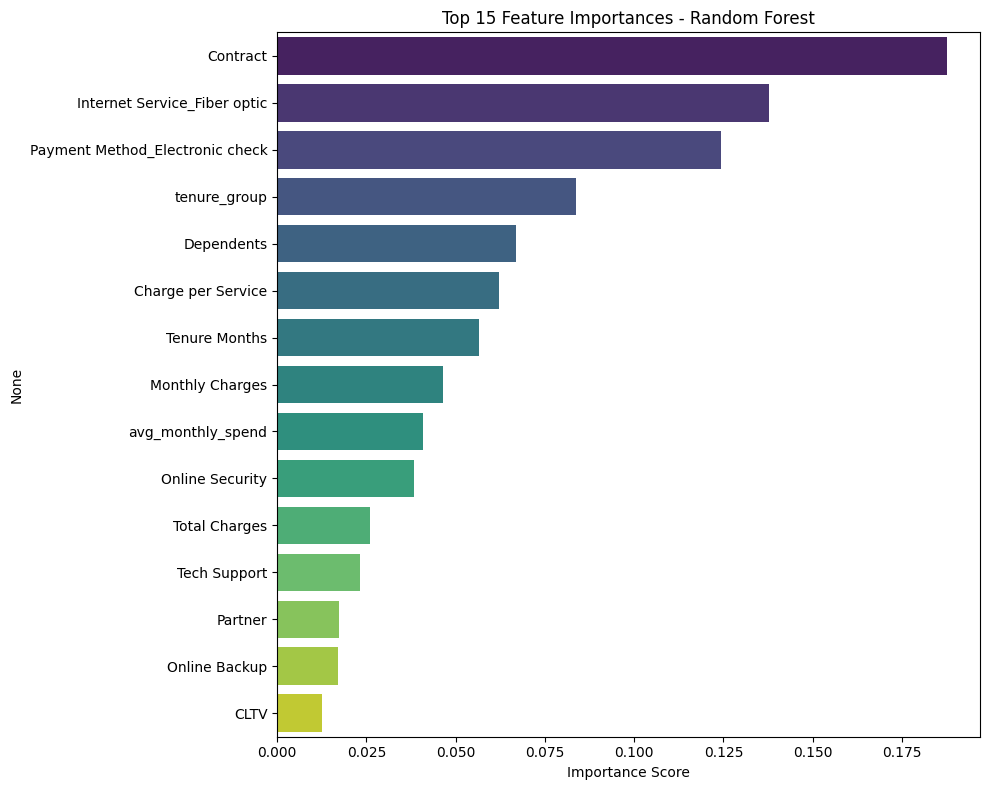

In [20]:
# ============================
# 7. Feature Importance (for tree models)
# ============================
if best_model_name in ['XGBoost', 'LightGBM', 'Random Forest', 'CatBoost']:
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_features = importances.nlargest(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [21]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.to_csv('feature_importance.csv', index=False)

In [22]:
# SHAP Setup
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np


c:\Users\DELL\miniconda3\envs\python_eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
 
# ── Which model to use as the PRIMARY SHAP model ──────────
# We use Random Forest since it was your best AUC model.
# You can change this to 'XGBoost', 'CatBoost', or 'LightGBM'.
PRIMARY_MODEL_NAME = 'Random Forest'
primary_model      = models[PRIMARY_MODEL_NAME]
 
print(f'PRIMARY SHAP model : {PRIMARY_MODEL_NAME}')
print(f'Test set size      : {X_test.shape}')
print(f'Features           : {X_test.shape[1]}')
 


PRIMARY SHAP model : Random Forest
Test set size      : (1409, 28)
Features           : 28


In [24]:
explainer = shap.TreeExplainer(primary_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

sv = np.array(sv)

if sv.ndim == 3:
    sv = sv[:, :, 1]

mean_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
print('\nTop 10 features by mean |SHAP|:')
print(mean_shap.head(10).round(4).to_string())




Top 10 features by mean |SHAP|:
Internet Service_Fiber optic       0.1009
Contract                           0.0988
Payment Method_Electronic check    0.0703
tenure_group                       0.0534
Dependents                         0.0484
Online Security                    0.0291
Tenure Months                      0.0226
Monthly Charges                    0.0219
Charge per Service                 0.0202
Tech Support                       0.0189


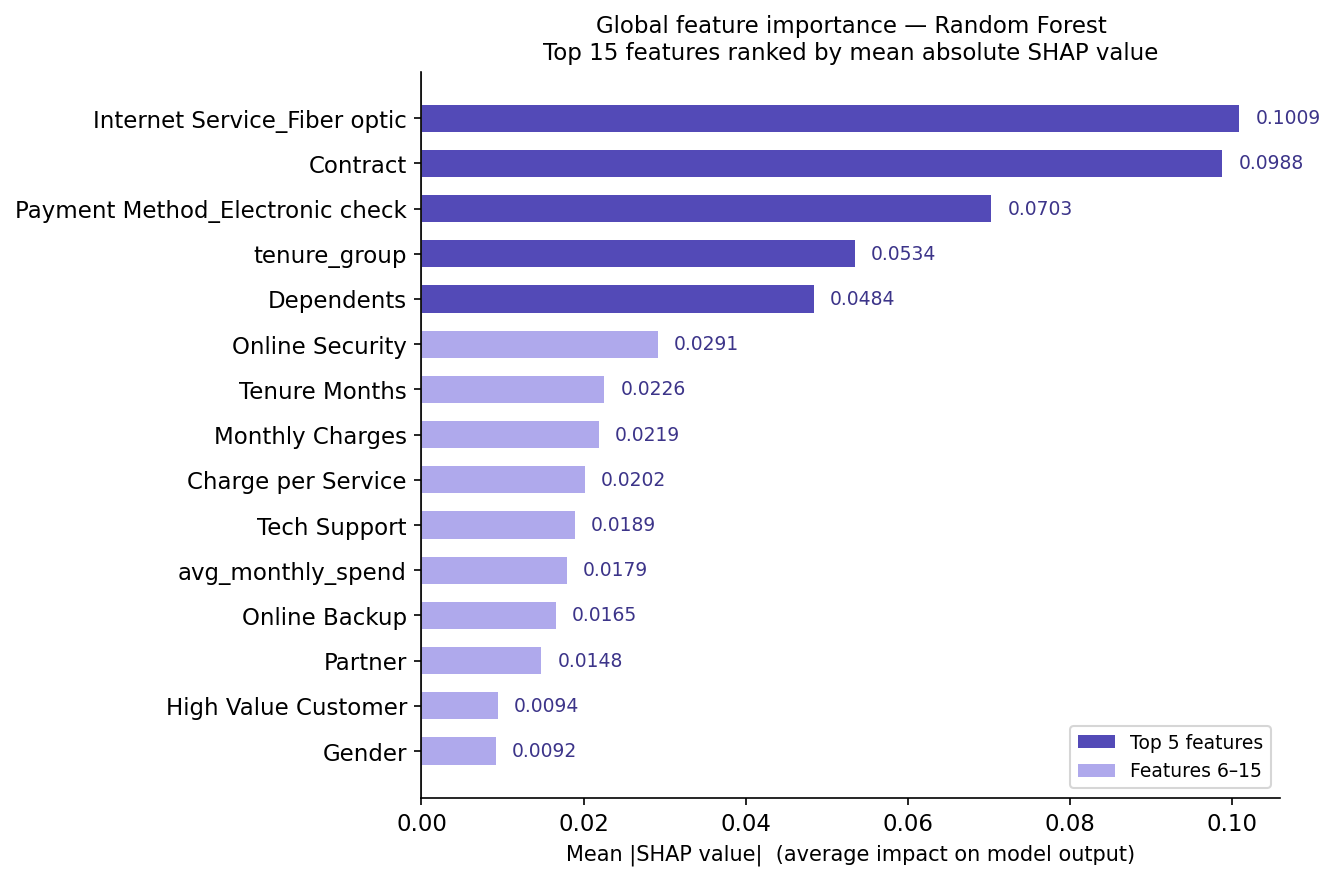

Saved: shap_plots/shap_bar_global.png


In [25]:
top_k = 15   # show top 15 features
 
fig, ax = plt.subplots(figsize=(9, 6))
 
top_feats  = mean_shap.head(top_k)
colors     = ['#534AB7' if i < 5 else '#AFA9EC'
               for i in range(top_k)]
 
bars = ax.barh(
    top_feats.index[::-1],
    top_feats.values[::-1],
    color    = colors[::-1],
    height   = 0.6,
    edgecolor= 'none'
)
 
# Value labels on bars
for bar, val in zip(bars, top_feats.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9,
            color='#3C3489')
 
ax.set_xlabel('Mean |SHAP value|  (average impact on model output)',
               fontsize=10)
ax.set_title(f'Global feature importance — {PRIMARY_MODEL_NAME}\n'
             f'Top {top_k} features ranked by mean absolute SHAP value',
             fontsize=11, fontweight='500')
ax.axvline(x=0, color='gray', linewidth=0.5)
 
# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#534AB7', label='Top 5 features'),
    Patch(facecolor='#AFA9EC', label='Features 6–15'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
 
plt.tight_layout()
plt.savefig('shap_plots/shap_bar_global.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_bar_global.png')

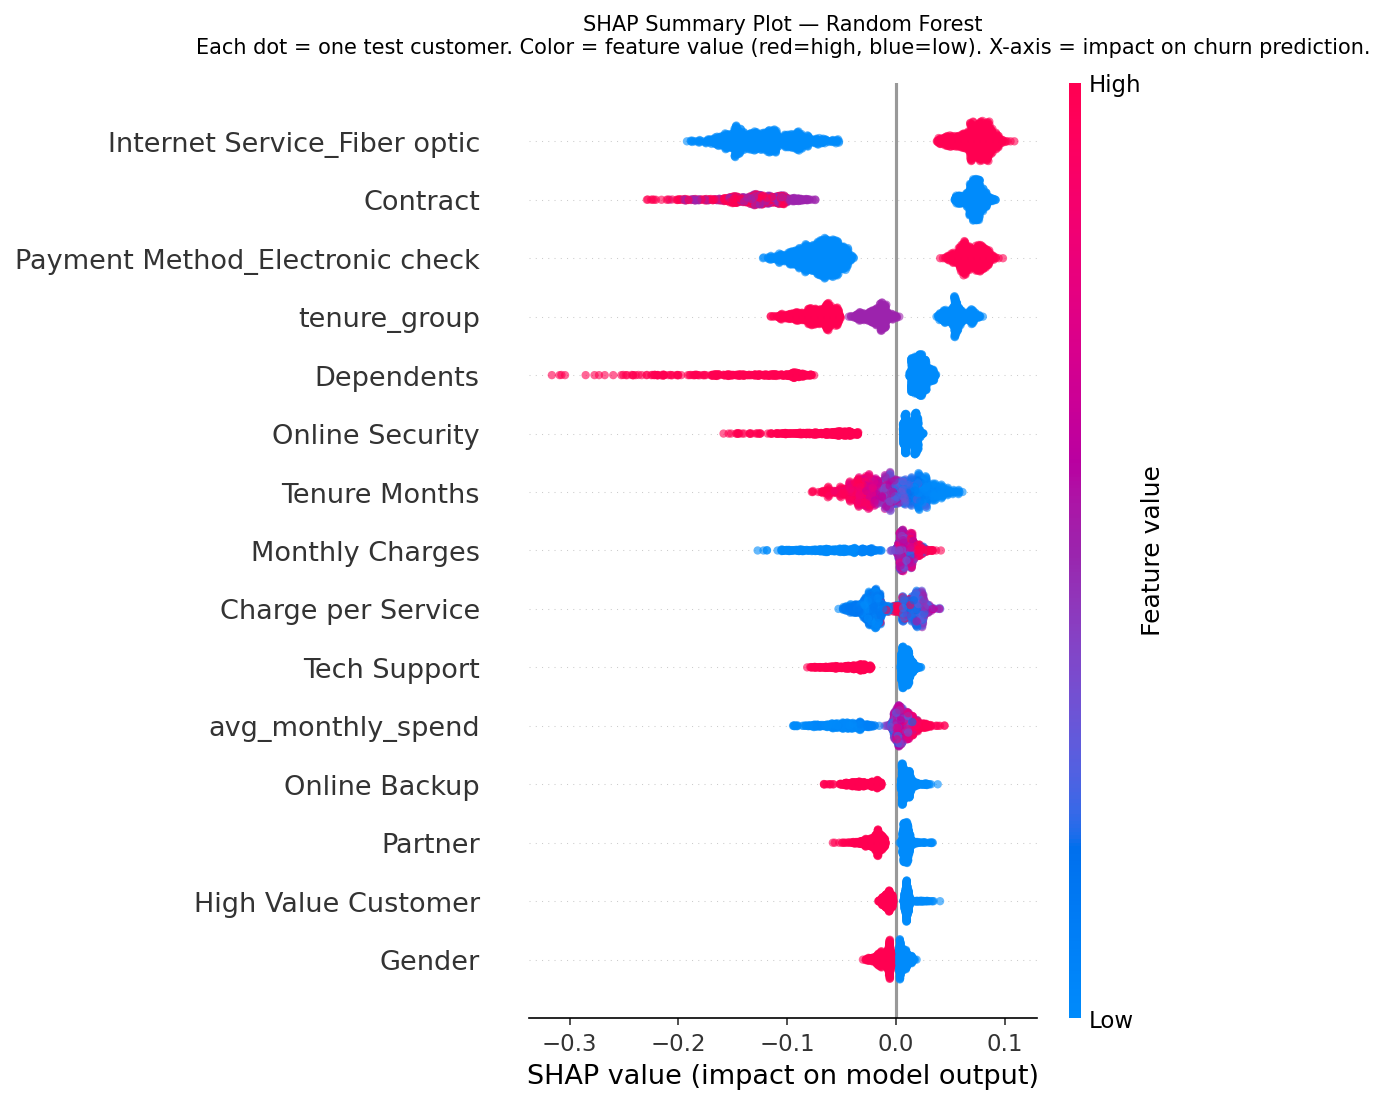

Saved: shap_plots/shap_beeswarm.png

HOW TO READ THIS CHART:
  - Right side (positive SHAP) = pushes prediction TOWARD churn
  - Left side (negative SHAP)  = pushes prediction AWAY from churn
  - Red dot = customer has HIGH value of this feature
  - Blue dot = customer has LOW value of this feature
  Example: Contract red dot on left = high contract value (2yr) protects from churn


In [26]:
# SHAP Summary Plot
fig, ax = plt.subplots(figsize=(10, 7))
 
shap.summary_plot(
    sv,
    X_test,
    max_display  = 15,
    show         = False,
    color_bar    = True,
    plot_type    = 'dot',    # 'dot' = beeswarm, 'bar' = bar chart
    alpha        = 0.6,
)
 
plt.title(f'SHAP Summary Plot — {PRIMARY_MODEL_NAME}\n'
          'Each dot = one test customer. '
          'Color = feature value (red=high, blue=low). '
          'X-axis = impact on churn prediction.',
          fontsize=10, pad=14)
 
plt.tight_layout()
plt.savefig('shap_plots/shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_beeswarm.png')
print()
print('HOW TO READ THIS CHART:')
print('  - Right side (positive SHAP) = pushes prediction TOWARD churn')
print('  - Left side (negative SHAP)  = pushes prediction AWAY from churn')
print('  - Red dot = customer has HIGH value of this feature')
print('  - Blue dot = customer has LOW value of this feature')
print('  Example: Contract red dot on left = high contract value (2yr) protects from churn')



High-risk customer index : 948
Churn probability        : 0.9452

Low-risk  customer index : 475
Churn probability        : 0.0022


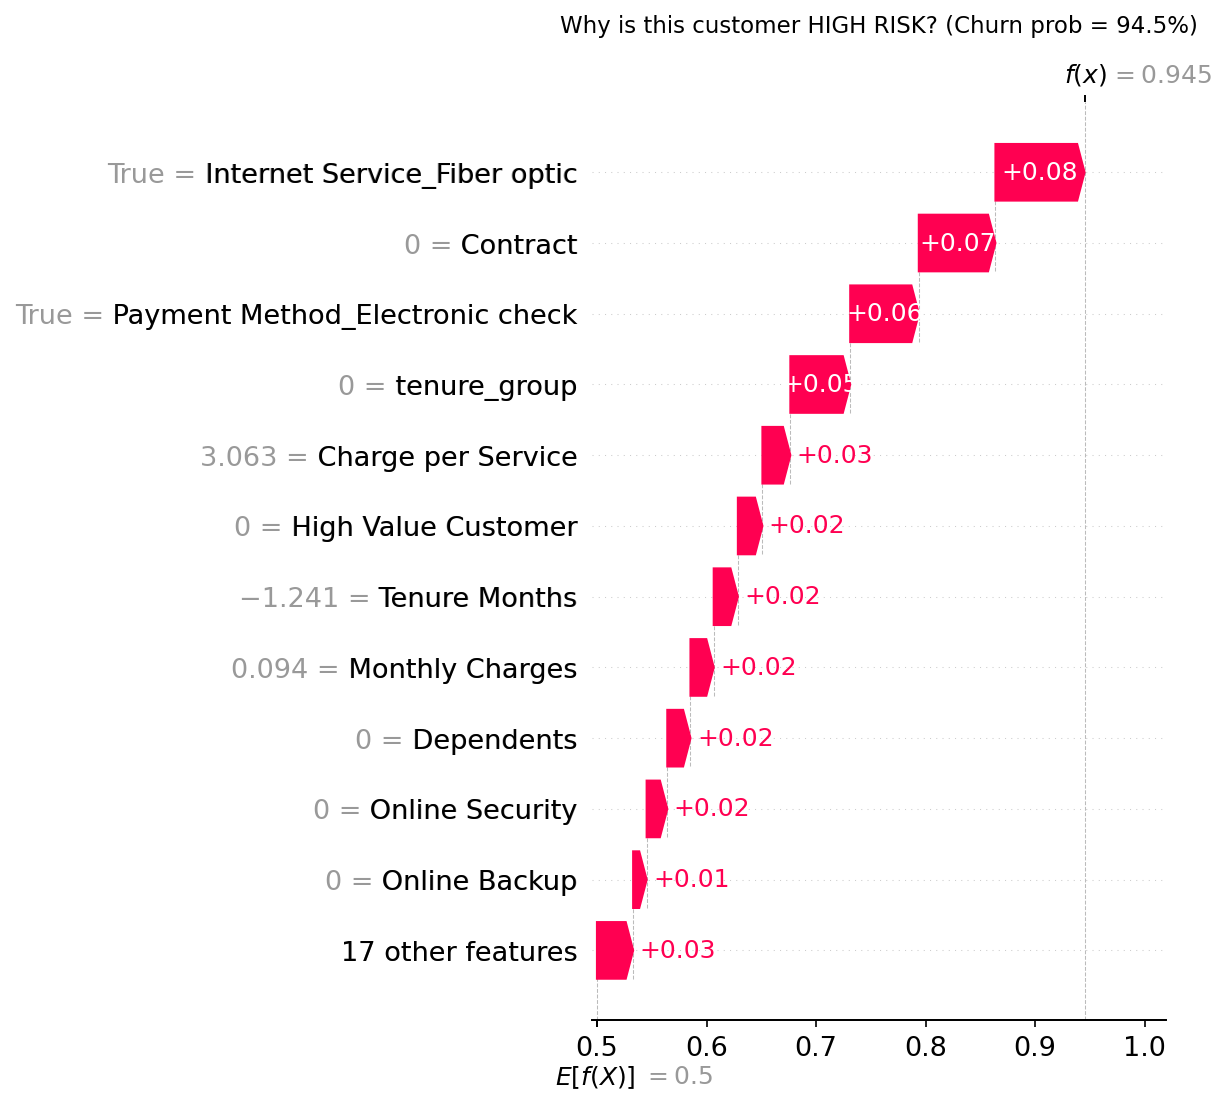

Saved: shap_plots/shap_waterfall_high_risk.png


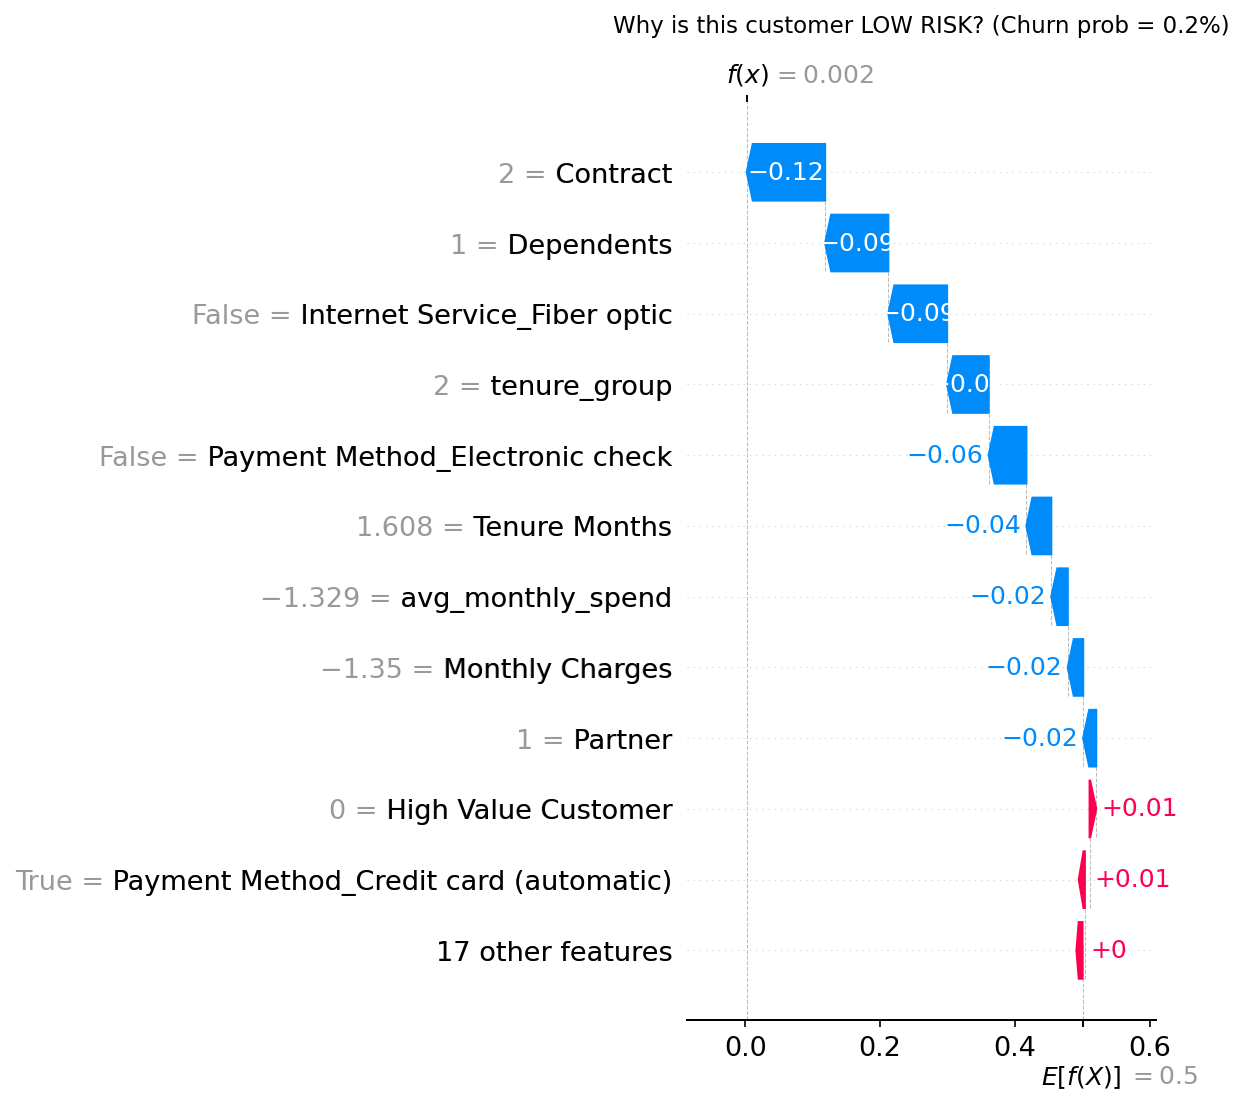

Saved: shap_plots/shap_waterfall_low_risk.png


In [27]:
#SHAP Waterfall Plot for a single customer
# Pick a high-risk customer (highest predicted churn probability)
y_proba_all = primary_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(y_proba_all)   # customer with highest churn prob
low_risk_idx  = np.argmin(y_proba_all)   # customer with lowest churn prob
 
print(f'\nHigh-risk customer index : {high_risk_idx}')
print(f'Churn probability        : {y_proba_all[high_risk_idx]:.4f}')
print(f'\nLow-risk  customer index : {low_risk_idx}')
print(f'Churn probability        : {y_proba_all[low_risk_idx]:.4f}')
 
# ── Waterfall for HIGH RISK customer ──────────────────────
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev = ev[1]   # class 1 expected value
 
shap_exp_high = shap.Explanation(
    values      = sv[high_risk_idx],
    base_values = ev,
    data        = X_test.iloc[high_risk_idx].values,
    feature_names = X_test.columns.tolist()
)
 
fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap_exp_high, max_display=12, show=False)
plt.title(f'Why is this customer HIGH RISK? (Churn prob = {y_proba_all[high_risk_idx]:.1%})',
          fontsize=11, fontweight='500', pad=14)
plt.tight_layout()
plt.savefig('shap_plots/shap_waterfall_high_risk.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_waterfall_high_risk.png')
 
# ── Waterfall for LOW RISK customer ───────────────────────
shap_exp_low = shap.Explanation(
    values      = sv[low_risk_idx],
    base_values = ev,
    data        = X_test.iloc[low_risk_idx].values,
    feature_names = X_test.columns.tolist()
)
 
fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap_exp_low, max_display=12, show=False)
plt.title(f'Why is this customer LOW RISK? (Churn prob = {y_proba_all[low_risk_idx]:.1%})',
          fontsize=11, fontweight='500', pad=14)
plt.tight_layout()
plt.savefig('shap_plots/shap_waterfall_low_risk.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_waterfall_low_risk.png')
 


Top 3 features for dependence plots: ['Internet Service_Fiber optic', 'Contract', 'Payment Method_Electronic check']


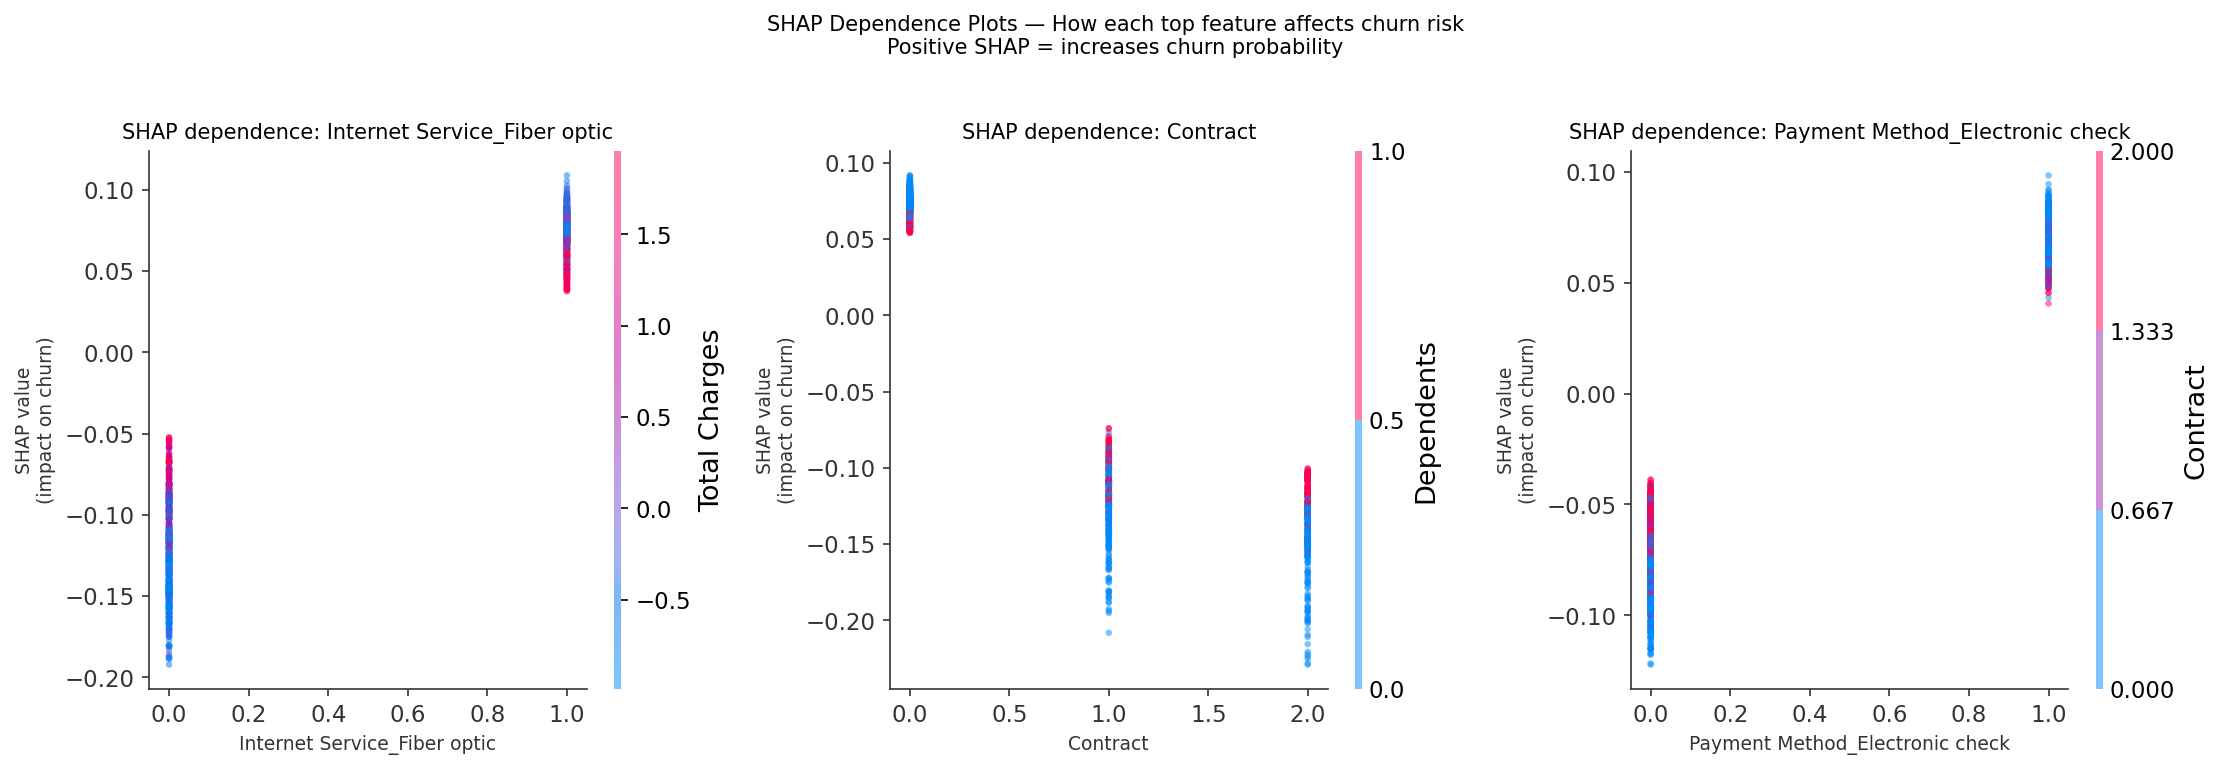

Saved: shap_plots/shap_dependence_top3.png


In [28]:
# SHAP Dependence Plot
top3 = mean_shap.head(3).index.tolist()
print(f'\nTop 3 features for dependence plots: {top3}')
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
for i, feat in enumerate(top3):
    ax = axes[i]
    feat_idx = X_test.columns.tolist().index(feat)
 
    shap.dependence_plot(
        feat,
        sv,
        X_test,
        ax           = ax,
        show         = False,
        dot_size     = 10,
        alpha        = 0.5,
        interaction_index = 'auto',   # auto-picks best interaction feature
    )
    ax.set_title(f'SHAP dependence: {feat}', fontsize=10, fontweight='500')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('SHAP value\n(impact on churn)', fontsize=9)
 
plt.suptitle('SHAP Dependence Plots — How each top feature affects churn risk\n'
             'Positive SHAP = increases churn probability',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('shap_plots/shap_dependence_top3.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_dependence_top3.png')
 


c:\Users\DELL\miniconda3\envs\python_eda\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


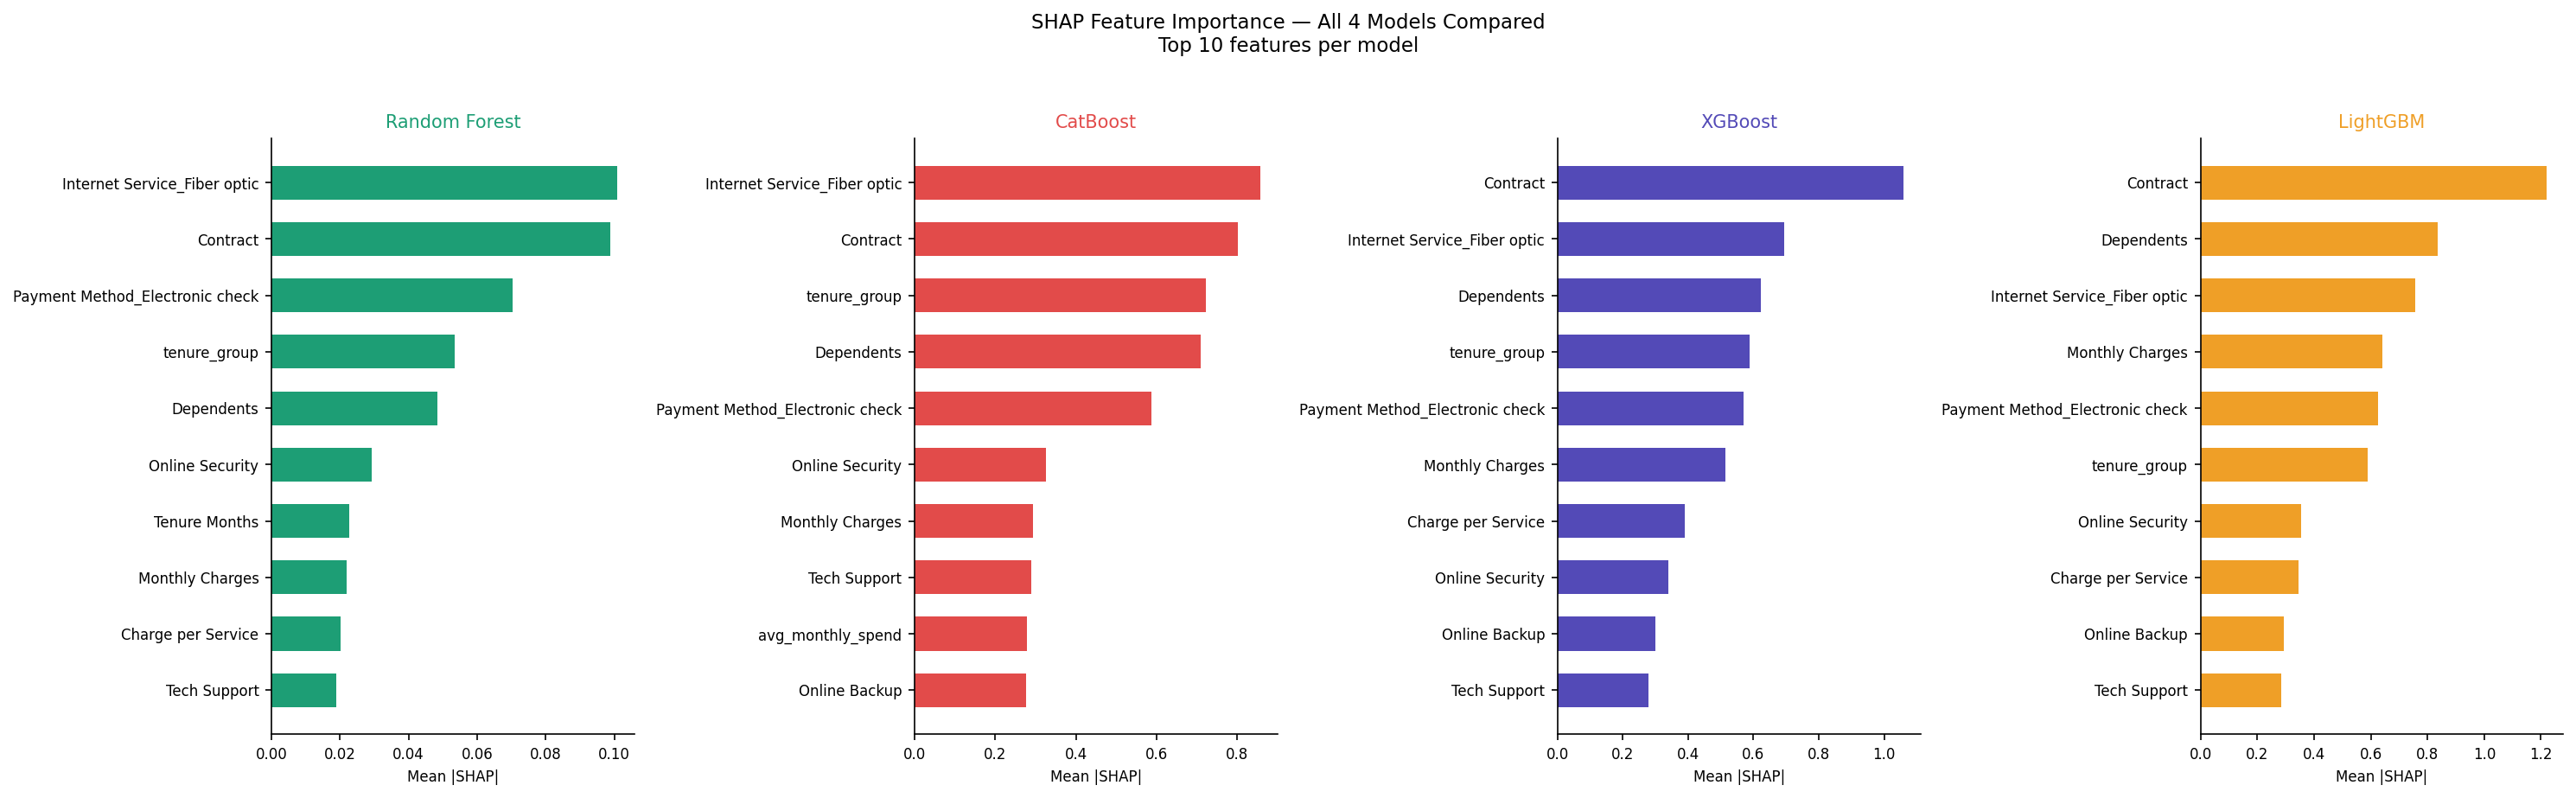

Saved: shap_plots/shap_all_models_comparison.png


In [29]:
# SHAP for all 4 Models
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
model_colors = {
    'Random Forest': '#1D9E75',
    'XGBoost'      : '#534AB7',
    'LightGBM'     : '#EF9F27',
    'CatBoost'     : '#E24B4A',
}
 
all_shap_data = {}   # store for Power BI export
 
for ax, (name, model) in zip(axes, models.items()):
    exp  = shap.TreeExplainer(model)
    svv  = exp.shap_values(X_test)
    svv  = svv[1] if isinstance(svv, list) else svv
    svv  = np.array(svv)
 
    if svv.ndim == 3:
        svv = svv[:, :, 1]
 
    ms = pd.Series(np.abs(svv).mean(axis=0), index=X_test.columns)
    ms = ms.sort_values(ascending=False).head(10)
 
    all_shap_data[name] = ms   # save for export
 
    ax.barh(ms.index[::-1], ms.values[::-1],
            color=model_colors[name], height=0.6, edgecolor='none')
    ax.set_title(name, fontsize=10, fontweight='500',
                 color=model_colors[name])
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
 
plt.suptitle('SHAP Feature Importance — All 4 Models Compared\n'
             'Top 10 features per model',
             fontsize=11, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('shap_plots/shap_all_models_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_all_models_comparison.png')
 



Generating SHAP direction analysis...


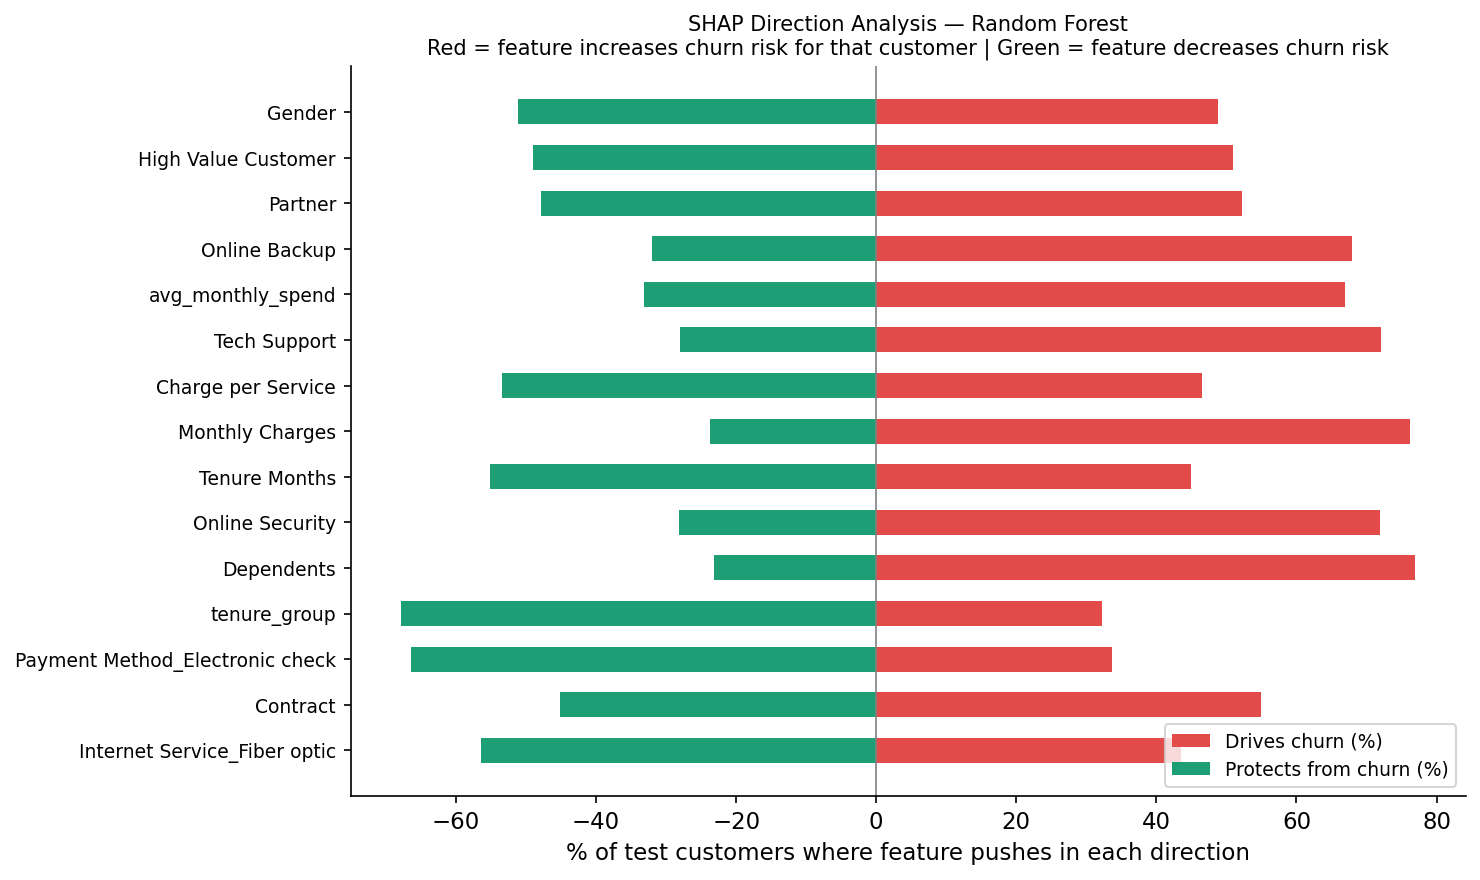

Saved: shap_plots/shap_direction_analysis.png


In [30]:
#SHAP Direction Analysis
print('\nGenerating SHAP direction analysis...')
 
# For the primary model
pct_positive = []   # % of customers where feature INCREASED churn prob
pct_negative = []   # % of customers where feature DECREASED churn prob
feature_names_list = []
 
for feat in mean_shap.head(15).index:
    feat_idx   = X_test.columns.tolist().index(feat)
    feat_shap  = sv[:, feat_idx]
    pct_pos    = (feat_shap > 0).mean() * 100
    pct_neg    = (feat_shap < 0).mean() * 100
    pct_positive.append(round(pct_pos, 1))
    pct_negative.append(round(pct_neg, 1))
    feature_names_list.append(feat)
 
direction_df = pd.DataFrame({
    'Feature'        : feature_names_list,
    'Mean_SHAP'      : mean_shap.head(15).values.round(4),
    'Pct_Drives_Churn'  : pct_positive,
    'Pct_Protects_Churn': pct_negative,
    'Model'          : PRIMARY_MODEL_NAME,
})
 
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(direction_df))
 
ax.barh(y_pos, direction_df['Pct_Drives_Churn'],
        color='#E24B4A', height=0.55, label='Drives churn (%)', edgecolor='none')
ax.barh(y_pos, -direction_df['Pct_Protects_Churn'],
        color='#1D9E75', height=0.55, label='Protects from churn (%)', edgecolor='none')
 
ax.set_yticks(y_pos)
ax.set_yticklabels(direction_df['Feature'], fontsize=9)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('% of test customers where feature pushes in each direction')
ax.set_title(f'SHAP Direction Analysis — {PRIMARY_MODEL_NAME}\n'
             'Red = feature increases churn risk for that customer | '
             'Green = feature decreases churn risk',
             fontsize=10)
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig('shap_plots/shap_direction_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: shap_plots/shap_direction_analysis.png')


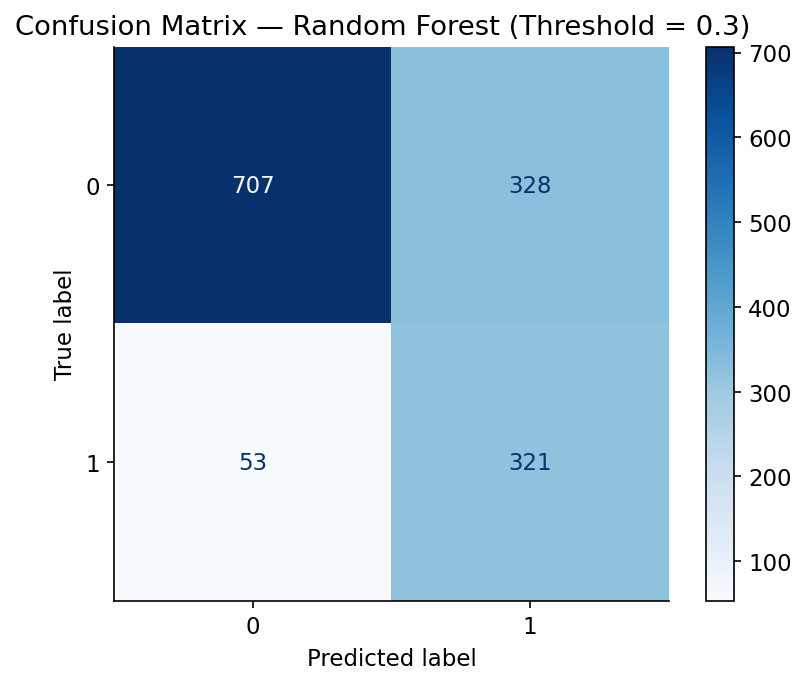

In [32]:
# Confusion Matrix for the best model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba_best >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name} (Threshold = {threshold})  ')
plt.show()


In [33]:
print('\n' + '='*55)
print('POWER BI CSV EXPORTS')
print('='*55)
 
# ── Export 1: All model metrics ───────────────────────────
metrics_rows = []
for name, model in models.items():
    yp   = model.predict(X_test)
    ypr  = model.predict_proba(X_test)[:,1]
    cm   = confusion_matrix(y_test, yp)
    tn_v, fp_v, fn_v, tp_v = cm.ravel()
    metrics_rows.append({
        'Model'             : name,
        'Accuracy'          : round(accuracy_score(y_test, yp), 4),
        'Precision'         : round(precision_score(y_test, yp, zero_division=0), 4),
        'Recall'            : round(recall_score(y_test, yp, zero_division=0), 4),
        'F1_Score'          : round(f1_score(y_test, yp, zero_division=0), 4),
        'ROC_AUC'           : round(roc_auc_score(y_test, ypr), 4),
        'Specificity'       : round(tn_v / (tn_v + fp_v), 4),
        'Balanced_Accuracy' : round((recall_score(y_test, yp, zero_division=0) + tn_v/(tn_v+fp_v))/2, 4),
        'TP': int(tp_v), 'FP': int(fp_v),
        'TN': int(tn_v), 'FN': int(fn_v),
        'Total_Test'        : len(y_test),
    })
 
model_metrics_df = pd.DataFrame(metrics_rows)
model_metrics_df.to_csv('powerbi_exports/01_model_metrics.csv', index=False)
print('Saved: powerbi_exports/01_model_metrics.csv')
print(model_metrics_df[['Model','Accuracy','Recall','F1_Score','ROC_AUC']].to_string(index=False))
 
# ── Export 2: Customer predictions (best model) ───────────
best_model_name = model_metrics_df.loc[model_metrics_df['ROC_AUC'].idxmax(), 'Model']
best_model      = models[best_model_name]
y_pred_best     = best_model.predict(X_test)
y_proba_best    = best_model.predict_proba(X_test)[:,1]
 
predictions_df = pd.DataFrame({
    'CustomerID'        : X_test.index,
    'Actual_Churn'      : y_test.values,
    'Predicted_Churn'   : y_pred_best,
    'Churn_Probability' : y_proba_best.round(4),
    'Risk_Tier'         : pd.cut(y_proba_best,
                                  bins=[0, 0.3, 0.6, 1.0],
                                  labels=['Low', 'Medium', 'High']).astype(str),
    'Correct_Prediction': (y_test.values == y_pred_best).astype(int),
    'Model_Used'        : best_model_name,
})
predictions_df.to_csv('powerbi_exports/02_customer_predictions.csv', index=False)
print(f'\nSaved: powerbi_exports/02_customer_predictions.csv')
print(f'  Best model: {best_model_name}')
print(f'  Rows: {len(predictions_df):,}')
print(f'  Columns: {list(predictions_df.columns)}')
 

# ── Export 3: Threshold analysis ──────────────────────────
thresholds = np.arange(0.1, 0.91, 0.05)
th_rows = []
for th in thresholds:
    yp_th = (y_proba_best >= th).astype(int)
    cm_th = confusion_matrix(y_test, yp_th)
    tn_t, fp_t, fn_t, tp_t = cm_th.ravel()
    th_rows.append({
        'Threshold'  : round(th, 2),
        'Precision'  : round(precision_score(y_test, yp_th, zero_division=0), 4),
        'Recall'     : round(recall_score(y_test, yp_th, zero_division=0), 4),
        'F1_Score'   : round(f1_score(y_test, yp_th, zero_division=0), 4),
        'Accuracy'   : round(accuracy_score(y_test, yp_th), 4),
        'Specificity': round(tn_t/(tn_t+fp_t), 4),
        'TP': int(tp_t), 'FP': int(fp_t), 'TN': int(tn_t), 'FN': int(fn_t),
        'Model'      : best_model_name,
    })
 
threshold_df = pd.DataFrame(th_rows)
threshold_df.to_csv('powerbi_exports/05_threshold_analysis.csv', index=False)
print(f'\nSaved: powerbi_exports/05_threshold_analysis.csv')
print(f'  Thresholds tested: {len(threshold_df)}')
 
print('\n' + '='*55)
print('ALL EXPORTS COMPLETE')
print('='*55)
print('Files in powerbi_exports/:')



POWER BI CSV EXPORTS
Saved: powerbi_exports/01_model_metrics.csv
        Model  Accuracy  Recall  F1_Score  ROC_AUC
Random Forest    0.7835  0.6684    0.6211   0.8447
     CatBoost    0.7878  0.5882    0.5954   0.8405
      XGBoost    0.7864  0.5856    0.5927   0.8341
     LightGBM    0.7807  0.5615    0.5761   0.8306

Saved: powerbi_exports/02_customer_predictions.csv
  Best model: Random Forest
  Rows: 1,409
  Columns: ['CustomerID', 'Actual_Churn', 'Predicted_Churn', 'Churn_Probability', 'Risk_Tier', 'Correct_Prediction', 'Model_Used']

Saved: powerbi_exports/05_threshold_analysis.csv
  Thresholds tested: 17

ALL EXPORTS COMPLETE
Files in powerbi_exports/:
